# Project 2: Data Visualization Basics

## Objective
Learn how to use visualizations to understand astronomical datasets and communicate findings.

## Introduction
Project 1 helped us get familiar with Stellar Classification Dataset - SDSS17, and introduced basic methods to understand datasets and communicate findings. In this Project, we will continue going over basic methods of studying data sets, but focus on visualizations. Tables and datasets are powerful in organizaing data but can be difficult to interpret. Sometimes it is much easier to interpret graphs than numbers. Data visualization is the graphical representation of information and data, and uses visual elements like charts, maps, and graphs. It is fundamental in data analysis because it transforms complex raw numbers into clear graphics. This will help us process information faster and spot patterns and trends, and therefore, make smarter descisions and inferences.


### Key Terminology
- Variable: a characteristic or measurement collected for each observtion
- Observation: a single row in the dataset representing one object
- Distribution: the overall pattern of how values are spread across a variable
- Frequency: the numbeer of times a value or category appears in a dataset.
- Distribution table: shows all the values of the variable along with the frequency of each one  

First, we import libraries and download the data set and examine the data. Run the cell below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sdss17 = pd.read_csv("../data/star_classification.csv")

sdss17.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


## Categorical Distributions
Data is not always numerical. Categorical data is information that sorts items into groups or categories using labels instead of numbers. There are two types of categorical data.
1) Nominal data: groups with no specific order (e.g eye color, gender)
2) Ordinal data: groups that follow a sequence of hierarchy (e.g school grades, socioeconomic status)

The SDSS 17 dataset contains data on 3 classifications of stars.

In [4]:
star_class = sdss17.value_counts('class')
star_class

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

The values of the categorical variable 'class' are galaxy, star, and quasar.

### Bar Chart
A bar chart compares different categories of information using rectangular bars where the length or height of each bar shows the amount or percentange for that specific category. The length of each bar is proportional to the frequency of the corresponding vategory.

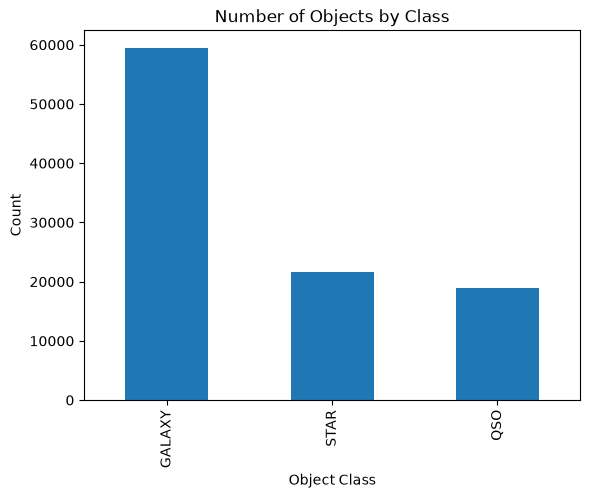

In [9]:
star_class.plot(kind='bar')

plt.title('Number of Objects by Class')
plt.xlabel('Object Class')
plt.ylabel('Count')
plt.show()

The bar chart is good for counts, frequencies, and comparing groups.

From this visualization, you can interpret which bar is tallest, which is least common, and if the dataset is balanced.

It is important to label graphs to provide clear context and ensure accurate data interpretation, and is a good habit to get into.

#### Question 1
What is the average redshift of each object class?

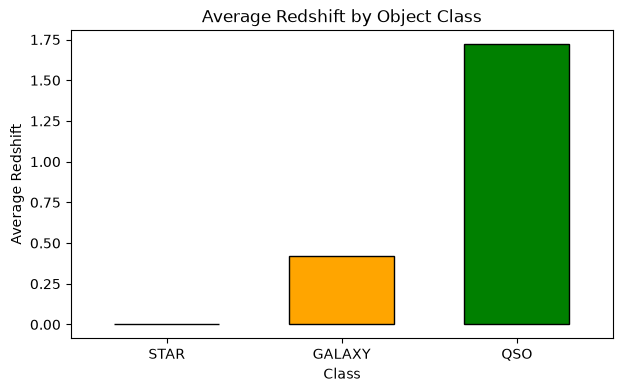

In [26]:
# Group by class, then work only with the redshift column and apply .mean()
avg_redshift = sdss17.groupby('class')['redshift'].mean()

avg_redshift.sort_values().plot(
    kind="bar",
    figsize=(7,4),
    color=["blue","orange","green"],
    edgecolor="black",
    width=0.6
)

plt.title("Average Redshift by Object Class")
plt.xlabel("Class")
plt.ylabel("Average Redshift")
plt.xticks(rotation=0)

plt.show()

Interpretation: An average negative redshift means the light is actually blueshifted, indicating the stars are moving closer to us (due to local stellar motion, orbital paths, or gravitational pull toward our solar system) The average redshift for stars is slightly negative (−0.000115) This is expected because stars in the Milky Way have individual motions relative to Earth. Some move toward us while others move away. In contrast, galaxies and especially quasars generally have positive redshifts because they are much farther away and the expansion of the universe causes them to recede from us.


#### Question 2
Which object class appears brightest in each filter?

<Axes: xlabel='class'>

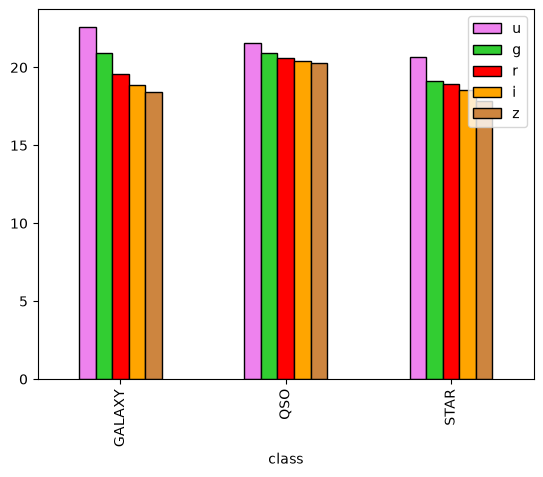

In [33]:
avg_mag = (
    sdss17
    .groupby("class")[["u","g","r","i","z"]]
    .mean()
)

avg_mag.plot(
    kind="bar",
    color = ['violet', 'limegreen', 'red', 'orange', 'peru'],
    edgecolor = 'black'
)

This is a grouped bar chart that lets us compare multiple variables across categories.

Interpretation: All three object classes have their highest average magnitudes in the u filter and generally lower average magnitudes toward the red and infrared filters. This indicates that, on average, these objects appear fainter in ultraviolet wavelengths than at longer wavelengths. The trend is strongest for stars, more gradual for galaxies, and least pronounced for quasars.

## Quantitative Distributions
Quantitative data are data represented numerically and can be measured, counted, and hav artihmetic performed on it, such as ages in a population or salaries in a company. There is discrete data, which are whole numbers that you can count (e.g numbers of students in a class, people in a household), and there is continuous data which is measurable and within a range (e.g a person's height, a car's speed).

Because they are numerical, you can perform mathematical operations on them, such as calculating averages, finding minimums and maximums, or creating histograms.

### Histograms
A histogram is a bar-style graph that shows the distribution of quantitative data, or how numbers are spead out over a range. They use bins, or continous intervals, and the height of each bin represents frequency.

Histograms are useful as they reveal the center, shape, and spread of a data set, and lets us spot normal distributions, skewness, or outliers.

#### Key Terminology
- Shape – What is the overall form of the distribution?
- Center – Where do most values cluster?
- Spread – How dispersed are the values?
- Outliers – Values that are much higher or lower than the rest.
- Skewness – Whether one tail is longer than the other.
- Modality - Amount of peaks
  

When looking at a histogram, ask yourself:

- Where are most observations?
- Is the distribution symmetric or skewed?
- Are there one or multiple peaks?
- Are there any outliers?
-How spread out are the values?

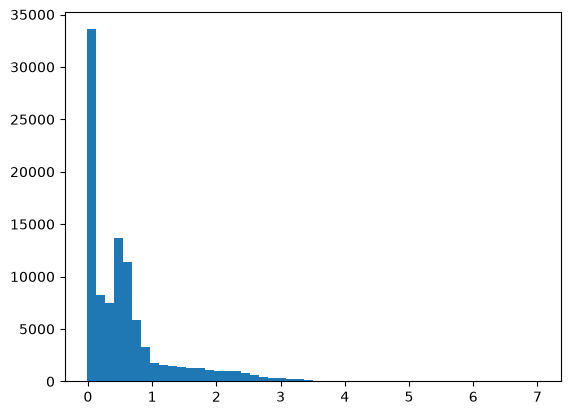

In [38]:
plt.hist(
    sdss17["redshift"],
    bins=50
)

plt.show()

Bins matter a lot because it completely changes the shape, look, and story of your data graph. If too small, it can look jagged and noisy, and if it's too large, it hides important details. If you find the right size, you can see clear groups and trends.

The best choice depends on the size of the dataset, the spread of the data, and the question you're trying to answer. 

#### Question 3
Compare the distribution of redshift for galaxies only.

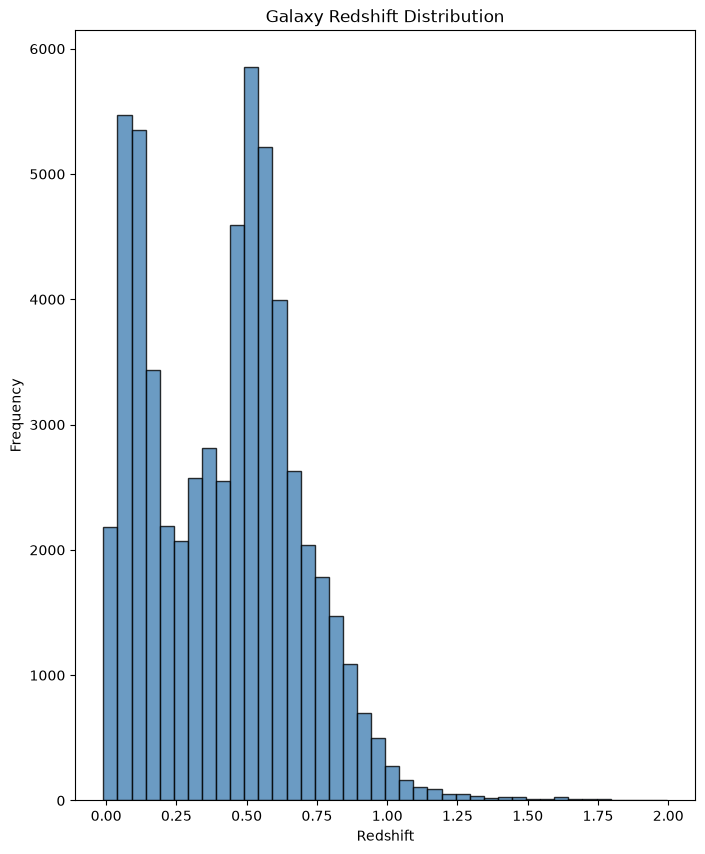

In [18]:
galaxies = sdss17[
    sdss17['class']=='GALAXY'
]

# Creates a figure, or a canvas that holds one or more plots
plt.figure(figsize=(8,10))

plt.hist(
    galaxies["redshift"],
    bins=40,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

plt.title("Galaxy Redshift Distribution")
plt.xlabel("Redshift")
plt.ylabel("Frequency")

plt.show()

Interpretation: The histogram of galaxy redshifts is bimodal and right-skewed. Most galaxies are concentrated in two distinct ranges of redshift, while a smaller number of galaxies have much larger redshift values, producing a long right tail.

#### Question 4
How do the redshift distributions of galaxies and quasars differ?

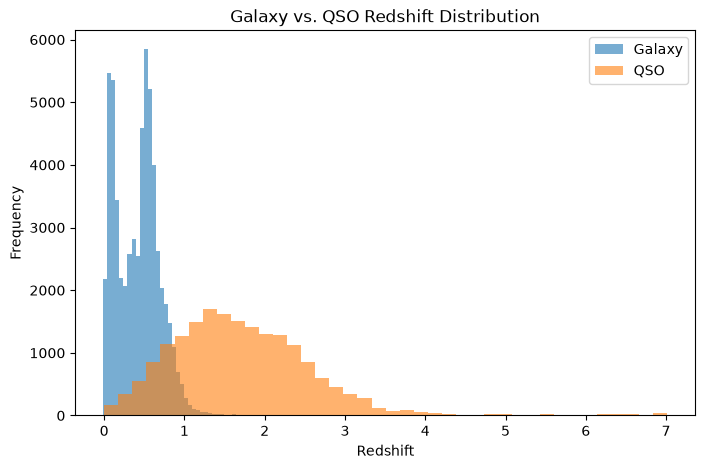

In [51]:
# Overlapping Histograms

plt.figure(figsize=(8,5))

# Plots distribution of redshift in galaxies
plt.hist(
    sdss17[sdss17["class"] == "GALAXY"]["redshift"],
    bins=40,
    alpha=0.6,  # Transparency
    label="Galaxy"
)

# Plots distribution of redshift in quasars
plt.hist(
    sdss17[sdss17["class"] == "QSO"]["redshift"],
    bins=40,
    alpha=0.6,  # Transparency
    label="QSO"
)

plt.title("Galaxy vs. QSO Redshift Distribution")
plt.xlabel("Redshift")
plt.ylabel("Frequency")
plt.legend()

plt.show()

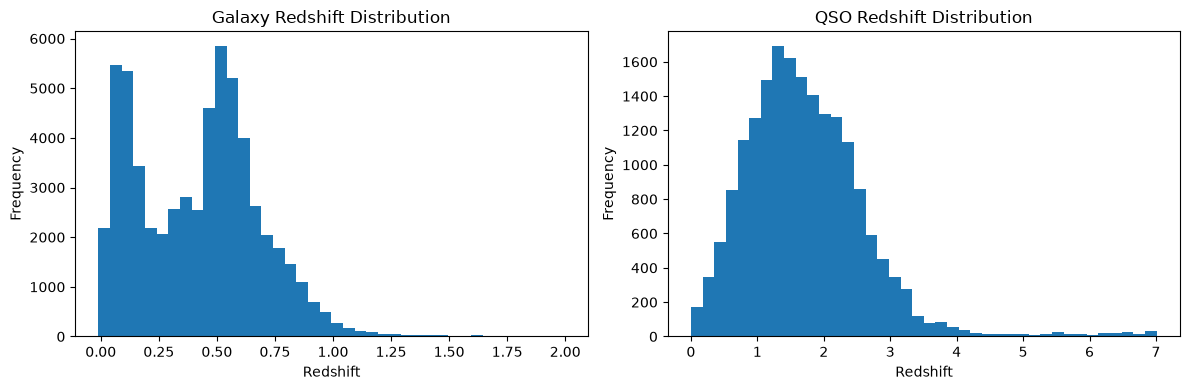

In [53]:
# Side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # creates one row, two columns, so two separate plots
# fig = a Figure object (entire canvas)
# axes = a collection of Axes objects (plotting region)

# Galaxy histogram
axes[0].hist(
    sdss17[sdss17["class"] == "GALAXY"]["redshift"],
    bins=40
)

axes[0].set_title("Galaxy Redshift Distribution")
axes[0].set_xlabel("Redshift")
axes[0].set_ylabel("Frequency")


# QSO histogram
axes[1].hist(
    sdss17[sdss17["class"] == "QSO"]["redshift"],
    bins=40
)

axes[1].set_title("QSO Redshift Distribution")
axes[1].set_xlabel("Redshift")
axes[1].set_ylabel("Frequency")


plt.tight_layout()  # adjusts spacing so titles and labels don't overlap
plt.show()

Subplots allow multiple visualizations to be displayed within one figure. They are useful when comparing related datasets while keeping each plot independent.

Interpretation: Comparing the two distributions, quasars have a much wider redshift range than galaxies. While galaxies in the sample mostly have redshifts between 0 and 2, quasars extend up to approximately 7. This reflects the fact that quasars are extremely luminous objects that can be observed at much greater distances. However, quasars occur less frequently in the dataset, resulting in lower overall frequencies compared to galaxies.

## More Visualizations
Line plots, box plots, and scatter plots are primarily used with quantitative data because they display numerical values and relationships between measurements. Not every plot needs only quantitative variables. A lot of real data visualization combines.

### Scatter Plot
A scatter plot is a graphb that uses dots to show the relationship between two numeric variables. The x-axis represents the independent variable, and the y-axis represents the dependent variable.

In scatter plots, there are three main patterns.
1. Positive correlation: As the x-value goes up, the y-value also goes up (slanted up and to the right).
2. Negative correlation: As the x-value goes up, the y-value goes down (slanted down and to the right).
3. No correlation: The dots are randomly spread out with no clear line or shape.

It's important to keep an eye out for two features-- outliers and a trendline. Outliers are single data points that sit far away from the main group of dots, and a trend line is an optional straight line added to show the general direction of the data.

The following shows the relationship between 'g' and 'r' magnitudes. First, we cleaned the data as astronomical catalogs often use placeholder values like -999. Real SDSS magnitudes should be positive values.

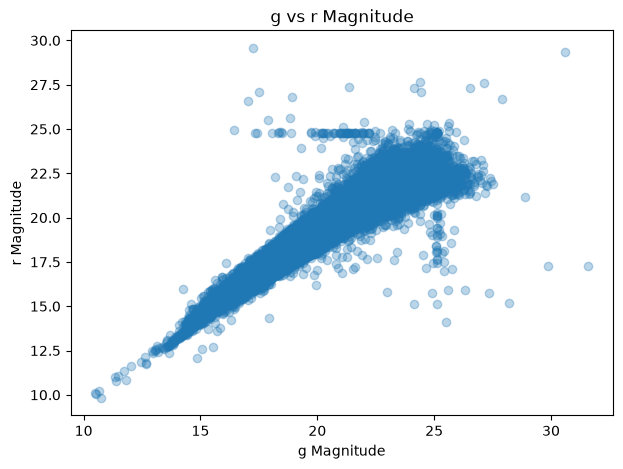

In [9]:
clean_sdss = sdss17[
    (sdss17["g"] > 0) &
    (sdss17["r"] > 0)
]

plt.figure(figsize=(7,5))

plt.scatter(
    clean_sdss["g"],
    clean_sdss["r"],
    alpha=0.3
)

plt.xlabel("g Magnitude")
plt.ylabel("r Magnitude")
plt.title("g vs r Magnitude")

plt.show()


#### Question 5
How does distance (redshift) relate to observed brightness (r magnitude)?

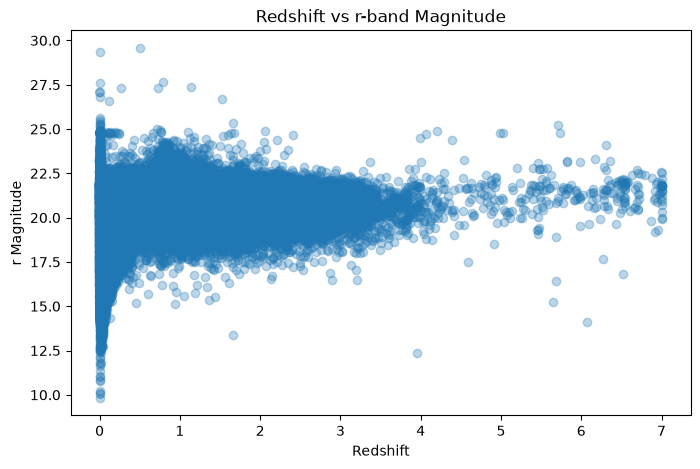

In [68]:
plt.figure(figsize=(8,5))

plt.scatter(
    clean_sdss["redshift"],
    clean_sdss["r"],
    alpha=0.3
)

plt.xlabel("Redshift")
plt.ylabel("r Magnitude")
plt.title("Redshift vs r-band Magnitude")

plt.show()

Interpretation: The scatter plot shows the relationship between redshift (a measurement related to distance) and r-band magnitude (observed brightness). Most objects are concentrated at lower redshift values, with fewer objects appearing at higher redshifts. The majority of observations have r magnitudes between approximately 15 and 25 and redshifts between 0 and 4. As redshift increases, the number of observed objects decreases, creating a less dense region at higher redshifts.

#### Question 6
How do stars separate based on color and brightness?

count    99999.000000
mean         0.985806
std          0.734675
min        -12.318610
25%          0.379810
50%          0.931460
75%          1.577985
max         14.315170
Name: g_r_color, dtype: float64

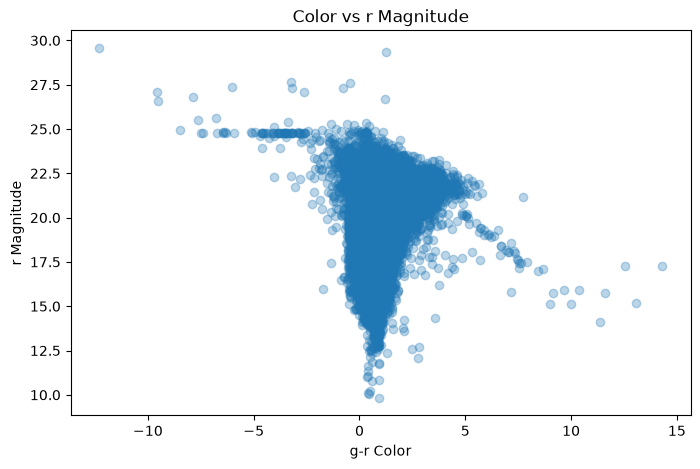

In [76]:
clean_sdss["g_r_color"] = clean_sdss["g"] - clean_sdss["r"]

plt.figure(figsize=(8,5))

plt.scatter(
    clean_sdss["g_r_color"],
    clean_sdss["r"],
    alpha=0.3
)

plt.xlabel("g-r Color")
plt.ylabel("r Magnitude")
plt.title("Color vs r Magnitude")

plt.show

clean_sdss["g_r_color"].describe()

The x-axis represents the g-r color index. Lower g-r values correspond to bluer objects because they emit relatively more light in the g-band filter, while higher g-r values correspond to redder objects because they emit relatively more light in the r-band filter.

Interpretation: Most objects cluster around g-r values near 0–1, with r magnitudes ranging from about 15–25. Redder objects appear more spread out toward lower r magnitudes, while bluer objects occupy a slightly different region of the plot. The large spread indicates that objects with similar colors can still have very different observed brightnesses.

### Box Plots
A box plot is a visual representation that shows how a set of numbers is spread out using quartiles. It summarizes a sample data using five key components.

- Minimum: the lowest data value (excluding extreme outliers)
- First Quartile (Q1): middle number of the lower half, marking 25% of the data
- Median: the middle value of the entire set, dividing the data in half
- Third Quartile (Q3): middle number of the upper half, marking 75% of the data
- Maximum: the highest data value (excluding extreme outliers)

The box represents the middle 50% of the data from Q1 to Q3, also called the interquartile range. The whiskers are lines that stretch out from the box to the minimm and maximum. Outliers are plotted using single dots that are past the whiskers.

Box plots are helpful for identifying the data center, spread, and outliers as it displays the core summary of a number set.

Text(0.5, 1.0, 'Redshift by Object Class')

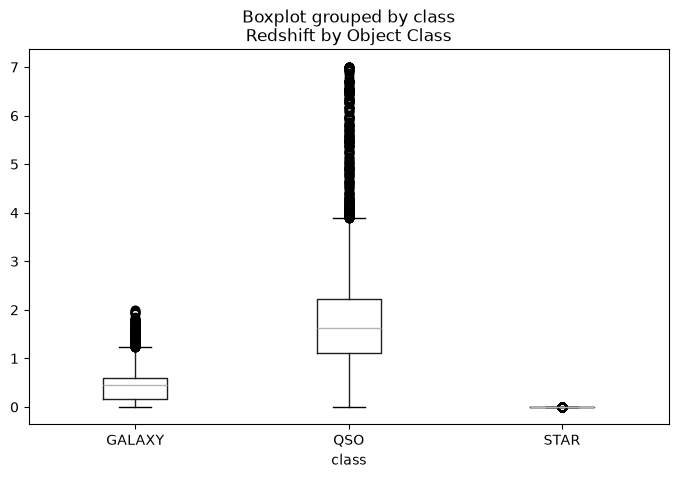

In [15]:
sdss17.boxplot(
    column="redshift",
    by="class",
    figsize=(8,5),
    grid=False
)

plt.title("Redshift by Object Class")

Interpretation: The box plot shows that the three object classes have very different redshift distributions. Stars have redshifts tightly concentrated around zero, resulting in a very small box. Galaxies have a wider central distribution and many high-redshift outliers, while QSOs show an even wider range of redshifts and numerous high-redshift values. This indicates that QSOs in this dataset generally reach much higher redshifts than stars and galaxies.

#### Question 7
Do different object classes have different distributions of r-band magnitudes?

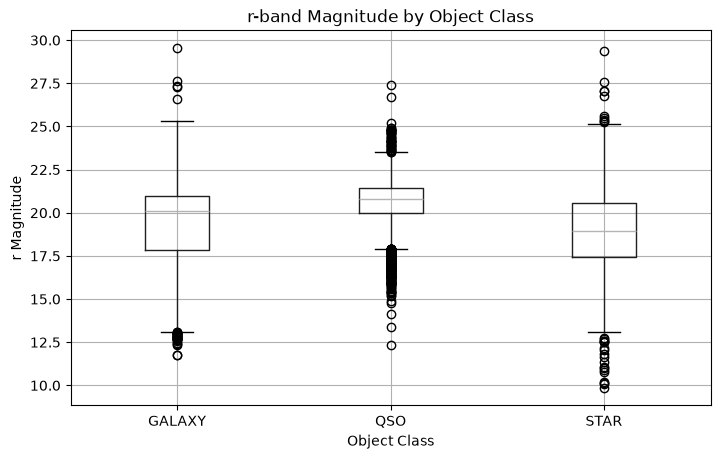

In [17]:
sdss17.boxplot(
    column="r",
    by="class",
    figsize=(8, 5),
    grid=True
)

plt.suptitle("")
plt.title("r-band Magnitude by Object Class")
plt.xlabel("Object Class")
plt.ylabel("r Magnitude")
plt.show()

Interpretation: The box plot shows that the three object classes have similar r-band distributions. Galaxy and stars have similar quartiles, medians, and minimums/maximums in this data set. Quasars have a narrower interquartile range, meaning the data points cluster closely together, but have many outliers. 

#### Question 8
How does the distribution of magnitude change across the SDSS filters for galaxies?

In [ ]:
galaxies.boxplot(
    column=["u", "g", "r", "i", "z"],
    figsize=(8, 5),
    grid=True
)

plt.suptitle("")
plt.title("Magnitude Across SDSS Filters For Galaxies")
plt.xlabel("Filters in the Photometric System")
plt.ylabel("Magnitude")
plt.show()

Interpretation: The box plot shows that the filters in the photometric systems are all distributed differently for galaxies in this data set. As wavelength increases from the u filter toward the z filter, the magnitude values generally decrease. The interquartile ranges grow more narrow, indicating that the middle 50% of galaxy magnitudes become more closely clustered at longer wavelengths, and also have more outliers.

### Line Charts
Line charts are often used to study chronological trends and patterns,  and connects data points with a straight line to show how numbers change over time. It uses a horizontal x-axis for time and a vertical y-axis for values. 

Line charts are useful in tracking trends, comparing groups, and identifying peak high points and low valley points in our data.

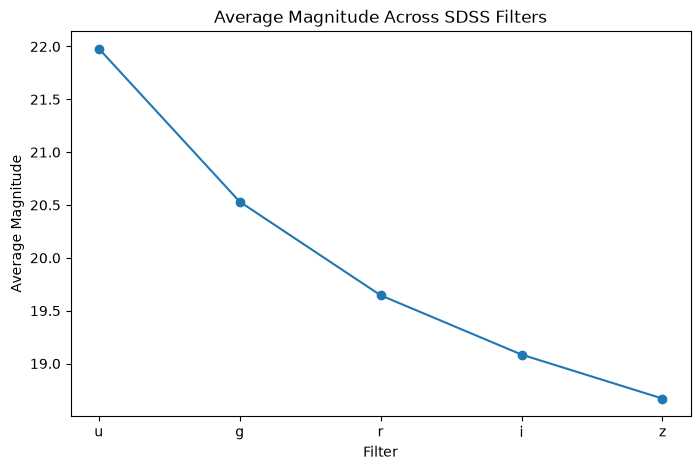

In [23]:
avg_mag = sdss17[["u", "g", "r", "i", "z"]].mean()

plt.figure(figsize=(8, 5))

plt.plot(avg_mag.index, avg_mag.values, marker="o")

plt.xlabel("Filter")
plt.ylabel("Average Magnitude")
plt.title("Average Magnitude Across SDSS Filters")

plt.show()

Interpretation: As wavelength increases from the u filter toward the z filter, the magnitude values generally decreases in our data set. The astronomical magnitude scale is inverse logarithmic. A lower magnitude number means a higher physical flux (brightness) This indidicates that the observed astronomical objects generally have higher measured brightness at the longer wavelengths.

#### Question 9
Do different object classes show different magnitude patterns across the filters?

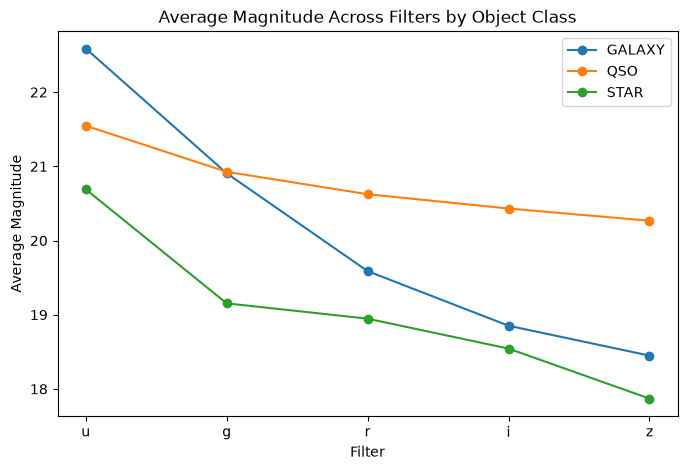

In [41]:
plt.figure(figsize=(8, 5))

for obj_class in ['GALAXY', 'QSO', 'STAR']:
    avg_mag = sdss17[
        sdss17["class"] == obj_class][
        ["u", "g", "r", "i", "z"]
    ].mean()
    plt.plot(avg_mag.index, avg_mag.values, marker="o", label=obj_class)

plt.plot()

plt.xlabel("Filter")
plt.ylabel("Average Magnitude")
plt.title("Average Magnitude Across Filters by Object Class")
plt.legend()

Interpretation: As wavelength increases from the u filter toward the z filter, the magnitude values generally decreases in our data set for galaxies and stars, while it remains steady for quasars and only decreases very slightly. 

#### Question 10
How does average redshift differ between object classes?

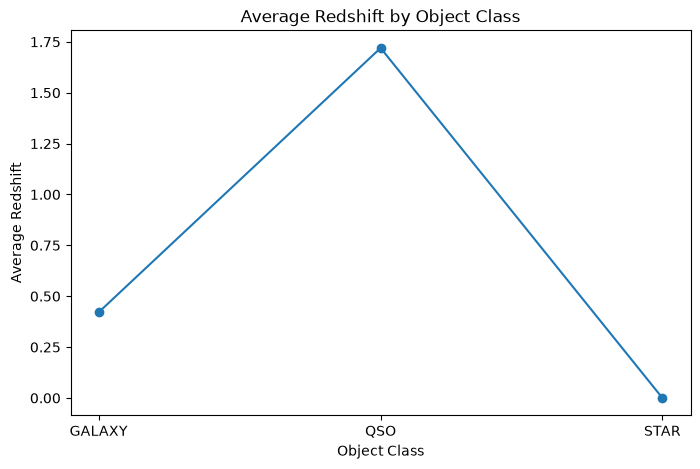

In [43]:
avg_redshift = sdss17.groupby("class")["redshift"].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    avg_redshift.index,
    avg_redshift.values,
    marker="o"
)

plt.xlabel("Object Class")
plt.ylabel("Average Redshift")
plt.title("Average Redshift by Object Class")

plt.show()

Interpretation: In this data set, quasars have the highest average redshift among the classes. Galaxies and stars are close to one another, but stars have the lowest average redshift, nearing 0.

## Deciding On A Graph
There are a lot of different kinds of graphs, and it may be difficult to decide on which one to use. To know what type of graph to use, you need to identify your main data goal, and it will help you match to the right format.

Bar Charts
- Goal: Compare values across different categories, groups, or items
- Examples: Comparing quantities between classes, or averages between classes

Histogram
- Goal: Show the frequency distribution of continuous numerical data grouped into numerical intervals called bins
- Examples: Displaying the distribution of a population's ages, or SAT score ranges in a group of students

Scatter Plots
- Goal: Display the relationship or correlation between two distinct numerical variables
- Examples: Plotting student study hours against final exam grades, or amount of sleep in hours against school years

Box Plots
- Goal: Visually summarizes the five-number statistical summary of a numerical data set
- Examples: Finding unusual high or low values, or summarizing massive amounts of continous data
Line Graph
- Goal: Track how a continous variable changes over time
- Examples: Showing daily temperature changes over a month, or a company's stock price across a given time


## Conclusion


In this project, I further explored the Sloan Digital Sky Survey (SDSS) dataset by learning visualizations and applying them to extract data for different goals. I learned how to inspect categorical data and quantitative data, key vocabulary for communicate findings, and how to interpret the visualizations. I learned how to display values and be able to identify the relationships and trends in the data.

From the analysis, I found that quasars have a wider range of redshift as they are extremely luminous objects that can be observed at much greater distances. I also observed that as wavelength increases from the u filter toward the z filter, the magnitude values generally decreases in our data set.

This and Project 1 helped me ask and answer several questions regarding the data, and gave me skills on investigating and communicating findings. In the next Project, I will apply expand these skills by learning the basics of statistics.